In [11]:
import fiona
fiona.listlayers ("../1_dataset/raw/processed/lagos_data.gpkg")

['lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222',
 'roads_lagos',
 'buildings_lagos',
 'pois_lagos',
 'buildings_clean',
 'roads_clean',
 'pois_clean']

In [10]:
# Load Cleaned Data

import geopandas as gpd
import matplotlib.pyplot as plt

gpkg_path = "../1_dataset/raw/processed/lagos_data.gpkg"


boundary = gpd.read_file (gpkg_path, layer = "lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222")
roads = gpd.read_file (gpkg_path, layer = "roads_clean")
buildings = gpd.read_file (gpkg_path, layer = "buildings_clean")
pois = gpd.read_file (gpkg_path, layer = "pois_clean")

In [24]:
# Summary Statistics

print ("Boundary polygons:", len(boundary))
print ("Cleaned Roads:", len(roads))
print ("Cleaned Buildings", len(buildings))
print ("Cleaned POIs:", len (pois))

# Reproject roads to a metric CRS (meters)

roads_m = roads.to_crs(epsg=3857)

# Compute road length in km

roads_length_km = roads_m.length.sum() / 1000
print("\nTotal Road Length (km):", round(roads_length_km, 2))

# --- Reproject boundary to metric CRS for area calculation

boundary_m = boundary.to_crs(epsg=3857)
boundary_area_sqkm = boundary_m.area.sum() / 1e6
print ("Boundary Area (sq km):", round(boundary_area_sqkm, 2))

# Show first few buildings records (to understand attributes)
print ("\nExample building attributes:")
display (buildings.head())

# Show first few POIs (to understand attributes)

print ("\nExample POI attributes:")
display (pois.head())


Boundary polygons: 2
Cleaned Roads: 2568
Cleaned Buildings 12212
Cleaned POIs: 143

Total Road Length (km): 432.72
Boundary Area (sq km): 32.73

Example building attributes:


,geometry
0,"MULTIPOLYGON (((3.39748 6.4464, 3.39776 6.4468..."
1,"MULTIPOLYGON (((3.3802 6.46813, 3.38023 6.4681..."
2,"MULTIPOLYGON (((3.38084 6.46767, 3.38097 6.468..."
3,"MULTIPOLYGON (((3.38116 6.46795, 3.38116 6.468..."
4,"MULTIPOLYGON (((3.39094 6.46105, 3.39141 6.461..."



Example POI attributes:


,fclass,geometry
0,market_place,"MULTIPOLYGON (((3.38331 6.4626, 3.38336 6.4626..."
1,market_place,"MULTIPOLYGON (((3.3912 6.46051, 3.39146 6.4606..."
2,park,"MULTIPOLYGON (((3.39585 6.44864, 3.39638 6.449..."
3,arts_centre,"MULTIPOLYGON (((3.39428 6.44899, 3.39446 6.449..."
4,pitch,"MULTIPOLYGON (((3.39449 6.45098, 3.39466 6.451..."


POIs counts by category:
 fclass
pitch               47
market_place        12
school              11
park                10
hospital             9
sports_centre        6
swimming_pool        5
clinic               3
graveyard            3
tower                3
hostel               3
mall                 2
embassy              2
courthouse           2
museum               2
police               2
stadium              2
shelter              2
university           2
hotel                2
lighthouse           1
water_tower          1
arts_centre          1
community_centre     1
theatre              1
water_works          1
track                1
college              1
bookshop             1
bank                 1
library              1
fire_station         1
supermarket          1
Name: count, dtype: int64


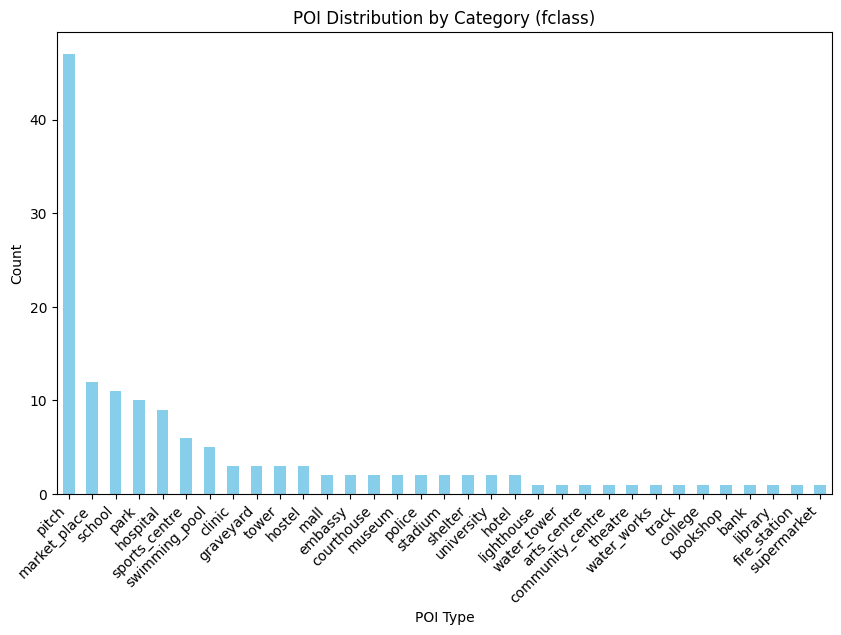

In [33]:
# POI Distribution by feature class (fclass)

import matplotlib.pyplot as plt

# Count POIs per category

poi_counts = pois ['fclass'].value_counts()
print ("POIs counts by category:\n", poi_counts)

#Plot POI distribution

plt.figure (figsize=(10,6))
poi_counts.plot(kind ='bar', color ='skyblue')
plt.title("POI Distribution by Category (fclass)")
plt.xlabel ("POI Type")
plt.ylabel ("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

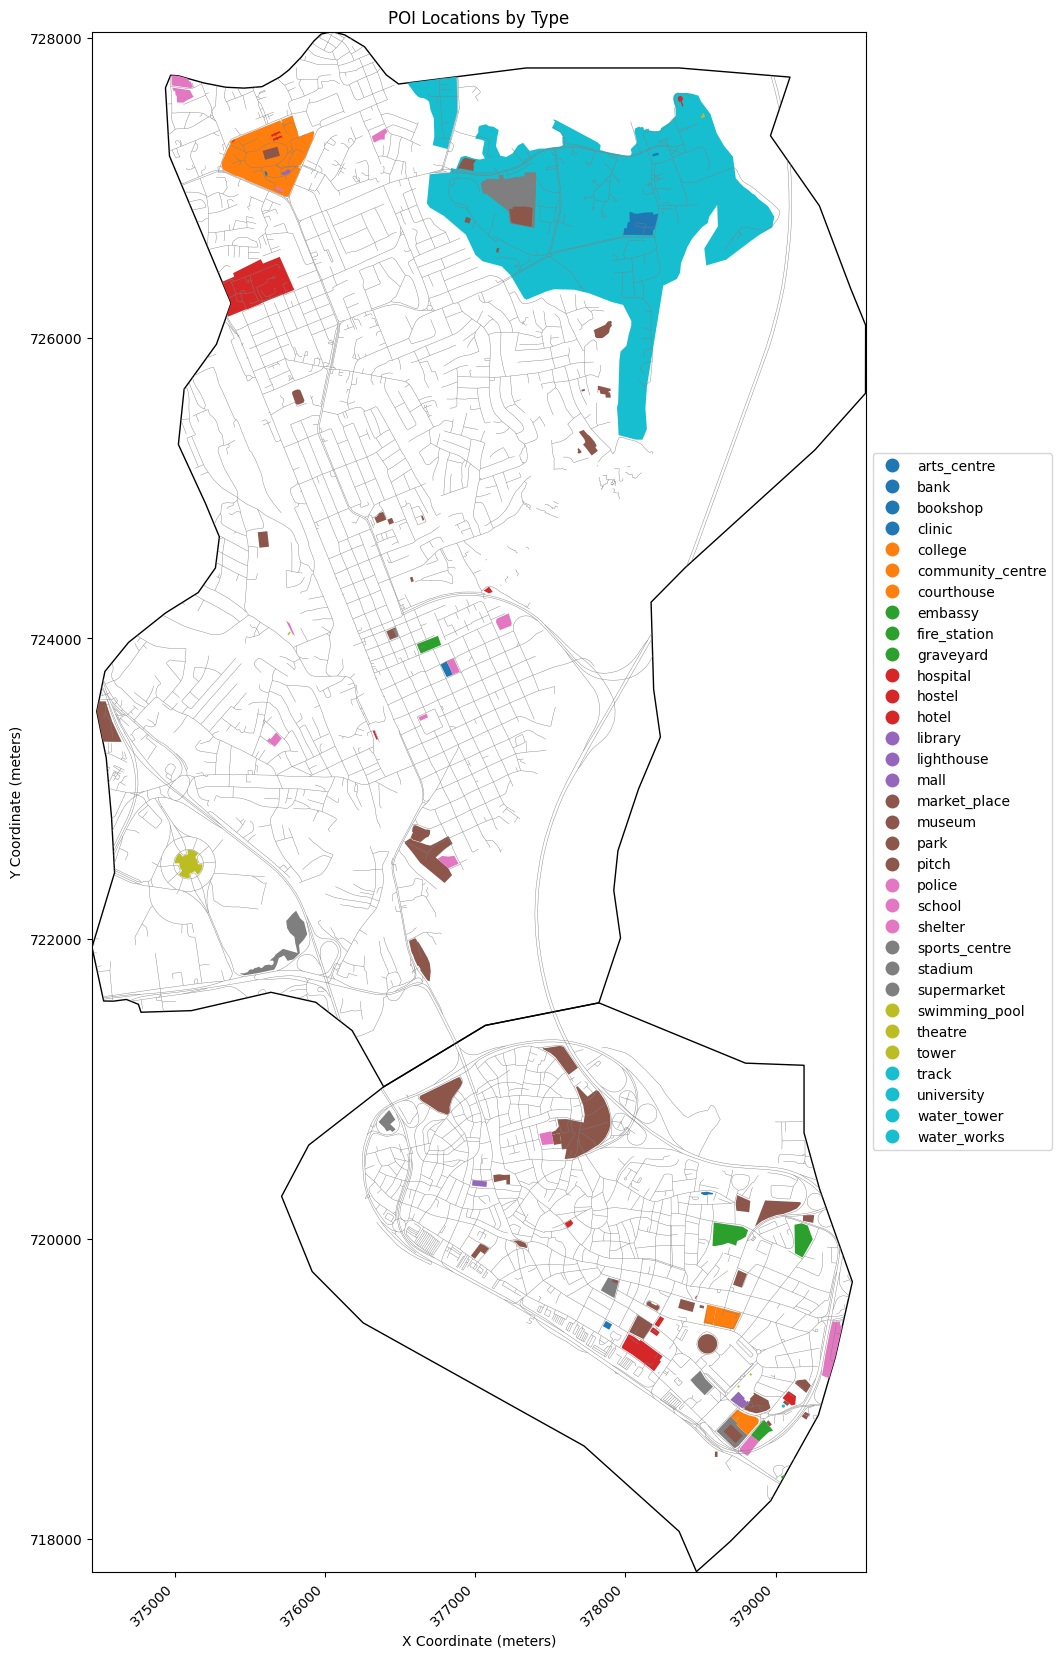

In [49]:
# Map of POIs by Category

#Reprojecting POIs to match metric CRS

pois_m = pois.to_crs(epsg=3857)
#Simple map: POIs colored by category
fig, ax = plt.subplots(figsize=(15,20))
boundary_m.plot (ax=ax, edgecolor = 'black', facecolor='none')
roads_m.plot (ax=ax, linewidth=0.3, color='grey')
pois_m.plot (ax=ax, column ='fclass', categorical=True, legend=True, markersize=30,
             legend_kwds={'bbox_to_anchor': (1, 0.5), 'loc':'center left'})

#Zoom to boundary
minx, miny, maxx, maxy = boundary_m.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

#Add Units to axes

ax.set_xlabel ("X Coordinate (meters)")
ax.set_ylabel("Y Coordinate (meters)")
plt.title ("POI Locations by Type")
plt.xticks(rotation =45 , ha = 'right')
plt.show()



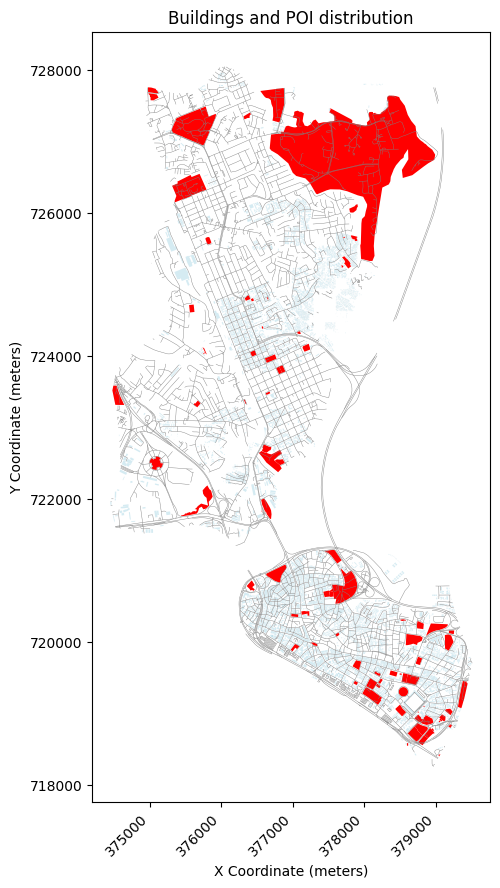

In [55]:
# Buildings + POIs Overlay

fig, ax = plt.subplots(figsize=(10,10))
roads_m.plot(ax=ax, linewidth=0.3, color= 'grey')
buildings_m = buildings.to_crs(epsg=3857)
buildings_m.plot(ax=ax, color='lightblue', alpha=0.5)
pois_m.plot (ax=ax, color='red', markersize =50)
plt.title ("Buildings and POI distribution")
plt.xlabel("X Coordinate (meters)")
plt.ylabel ("Y Coordinate (meters)")
plt.xticks(rotation =45, ha ='right')
plt.show()

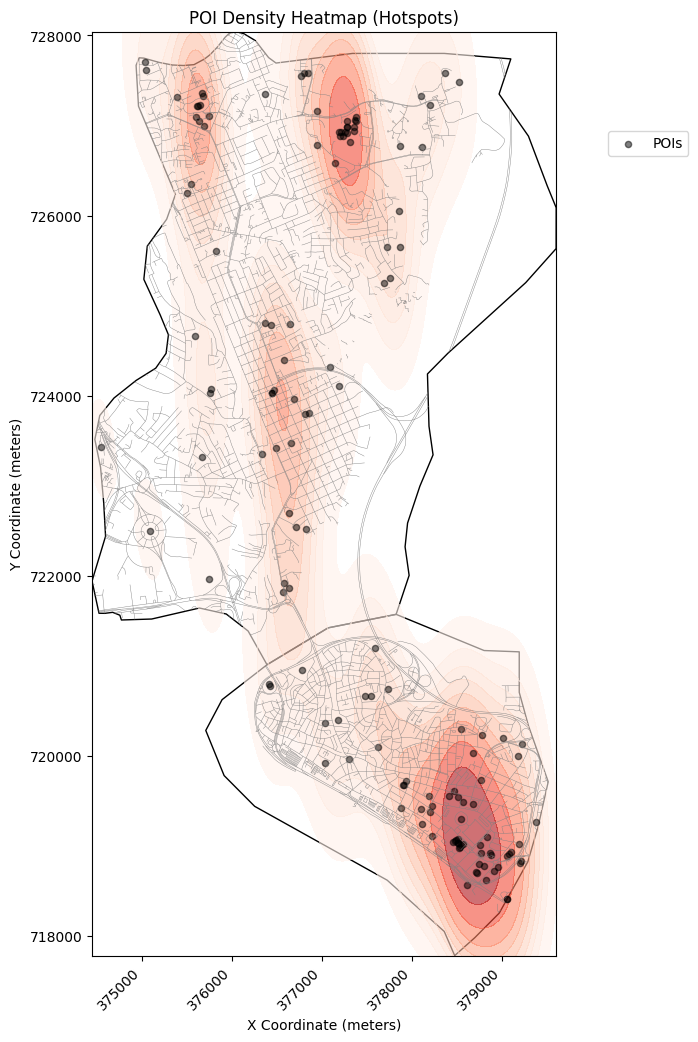

In [77]:
import seaborn as sns 
import pandas as pd

#COmpute centroids for POIs

pois_m ['centroid'] = pois_m.geometry.centroid

# Extract Coordinates

poi_coords = pd.DataFrame({
    'x': pois_m.centroid.x,
    'y':pois_m.centroid.y
})

#Plot density heatmap

fig, ax = plt.subplots(figsize =(12,12))
boundary_m.plot (ax=ax, edgecolor='black', facecolor='none')
roads_m.plot(ax=ax, linewidth=0.3, color ='grey')

sns.kdeplot(
    data=poi_coords, x='x', y = 'y', fill = True, cmap = 'Reds', bw_adjust=0.5, ax=ax, alpha=0.6
)

ax.scatter (poi_coords['x'], poi_coords['y'], s=20, color ='black', alpha=0.5, label ='POIs')

# Zoom to boundary
minx, miny, maxx, maxy = boundary_m.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_xlabel("X Coordinate (meters)")
ax.set_ylabel ("Y Coordinate (meters)")
plt.title ("POI Density Heatmap (Hotspots)")
plt.xticks (rotation=45, ha ='right')
ax.legend(loc='upper right', bbox_to_anchor = (1.3, 0.9))
plt.show()
